Before:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
After:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


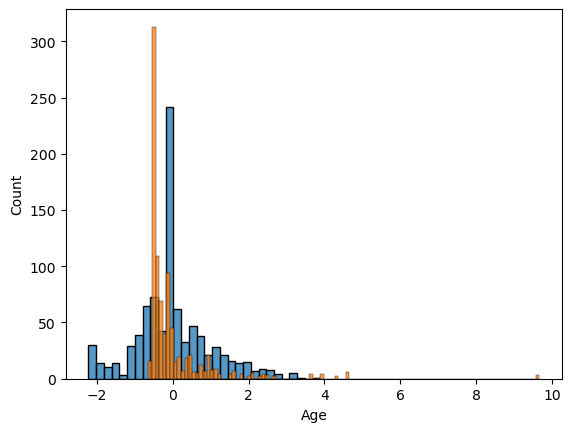

In [14]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("../data/raw/titanic.csv")

print("Before:\n", df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

for col in ['Sex','Embarked','Pclass']:
    df[col] = LabelEncoder().fit_transform(df[col])

scaler = StandardScaler()
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

print("After:\n", df.isnull().sum())

sns.histplot(df['Age']); sns.histplot(df['Fare'])

df.to_csv("../data/processed/train", index="False")


In [16]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

df["Fare_per_person"] = df["Fare"] / df["FamilySize"]

df["Age_bin"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 40, 60, 80],
    labels=["Child", "Teen", "Adult", "MiddleAge", "Senior"],
)

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [ ]:
df = pd.read_csv("../data/raw/train.csv")
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
print(missing)

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
df['GarageType'] = df['GarageType'].fillna("Missing")


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

num_cols = ["Age", "Fare", "SibSp", "Parch"]
cat_cols = ["Sex", "Embarked", "Pclass"]
num_pipe = Pipeline(
    [("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]
)
cat_pipe = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)
prep = ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])
full_pipe = Pipeline(
    [
        ("prep", prep),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42)),
    ]
)
df = pd.read_csv("../data/raw/titanic.csv")
X = df[num_cols + cat_cols]
y = df["Survived"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
full_pipe.fit(Xtr, ytr)
print(f"Accuracy: {accuracy_score(yte, full_pipe.predict(Xte)):.4f}")

joblib.dump(
    {"pipeline": full_pipe, "num_cols": num_cols, "cat_cols": cat_cols},
    "titanic_pipeline.joblib",
)
loaded = joblib.load("titanic_pipeline.joblib")

Accuracy: 0.8156


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

titanic = pd.read_csv("../data/raw/titanic.csv")

# Inspect dataset
# print(titanic.head())
# print(titanic.info())

# Select useful features
features = ["Age", "Fare", "SibSp", "Parch", "Sex", "Pclass", "Embarked"]
X = titanic[features]
y = titanic["Survived"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for numeric and categorical
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
categorical_features = ["Sex", "Pclass", "Embarked"]

# Numeric pipeline:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Build full pipeline with model
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train model
clf.fit(X_train, y_train)

# Evaluate
print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))


Train accuracy: 0.8103932584269663
Test accuracy: 0.7988826815642458


In [27]:
titanic = pd.read_csv("../data/raw/titanic.csv")
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
